# PAPER 원장 복원·주문결과 리플레이·재진입 실험

## 결론

- 5억원 대비 손실은 컷오프 총평가액으로 직접 확인되는 실제 손실이다.
- 주문별 실현손익은 executions 누락, 초기 체결가 누락, 수량 불일치 때문에 완전 복원할 수 없다. 따라서 확정 손익과 미복원 조정항목을 분리한다.
- 재진입 확인 조건은 최근 구간의 손실과 회전율을 줄였지만 전체 구간 수익률을 희생했다. 즉시 운영 반영이 아니라 PAPER shadow 비교가 적절하다.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
LEDGER = ROOT / 'reports' / 'analysis' / 'paper_ledger_2026-07-22'
REENTRY = ROOT / 'reports' / 'analysis' / 'paper_reentry_experiments'

ledger = json.loads((LEDGER / 'summary.json').read_text(encoding='utf-8'))
pnl = pd.read_csv(LEDGER / 'pnl_attribution.csv')
orders = pd.read_csv(LEDGER / 'order_lifecycle.csv')
positions = pd.read_csv(LEDGER / 'position_reconciliation.csv')
daily_nav = pd.read_csv(LEDGER / 'daily_nav.csv')
full = json.loads((REENTRY / 'full' / 'metrics.json').read_text(encoding='utf-8'))
recent = json.loads((REENTRY / 'pass_only' / 'metrics.json').read_text(encoding='utf-8'))

print('Cutoff:', ledger['metadata']['cutoff'])
print('Mode:', ledger['metadata']['mode'])
print('Data quality:', ledger['data_quality']['overall_grade'])

Cutoff: 2026-07-22T10:57:42+09:00
Mode: PAPER
Data quality: LOW_FOR_TRADE_LEVEL_PNL__HIGH_FOR_ENDPOINT_PNL


## 5억원 기준 원장

In [2]:
endpoint = pd.DataFrame([
    {'metric': '시작자금', 'value': ledger['metadata']['starting_capital']},
    {'metric': '컷오프 총평가액', 'value': ledger['endpoint']['total_asset']},
    {'metric': '총손익', 'value': ledger['endpoint']['total_pnl']},
    {'metric': '총수익률', 'value': ledger['endpoint']['total_return']},
    {'metric': '기준선 이후 손익', 'value': ledger['endpoint']['post_baseline_pnl']},
    {'metric': '기준선 이후 수익률', 'value': ledger['endpoint']['post_baseline_return']},
])
endpoint

,metric,value
0,시작자금,5.000000e+08
1,컷오프 총평가액,4.717951e+08
2,총손익,-2.820487e+07
3,총수익률,-5.640974e-02
4,기준선 이후 손익,8.769539e+06
5,기준선 이후 수익률,1.893964e-02


C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\556300614.py:8: UserWarning: Glyph 48177 (\N{HANGUL SYLLABLE BAEG}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\556300614.py:8: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\556300614.py:8: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\556300614.py:8: UserWarning: Glyph 50613 (\N{HANGUL SYLLABLE EOG}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\556300614.py:8: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\556300614.py:8: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from current font.
  plt.tight_

C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) 

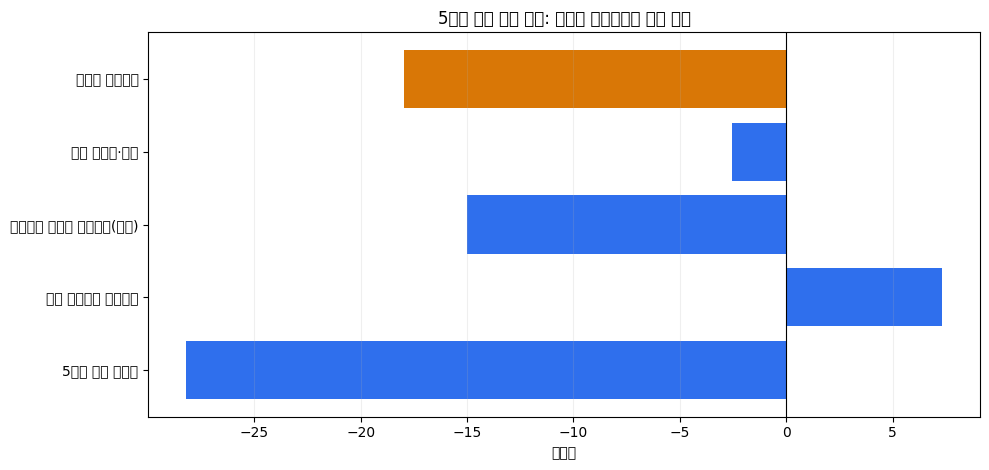

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.8))
colors = ['#2f6fed' if c != 'UNRESOLVED_BALANCING_ITEM' else '#d97706' for c in pnl['classification']]
ax.barh(pnl['component'], pnl['amount'] / 1_000_000, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('백만원')
ax.set_title('5억원 대비 손익 구성: 미복원 조정항목을 별도 표시')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

현재 보유 평가손익과 일부 매칭된 실현손익만으로는 전체 손실을 설명할 수 없다. 잔여분은 초기 보유, 누락 체결, 실제 수수료·세금, 외부 변동이 섞인 조정항목이며 임의 거래로 만들지 않는다.

## 주문결과 리플레이와 데이터 품질

C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\338317222.py:7: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\338317222.py:7: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\338317222.py:7: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\338317222.py:7: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\338317222.py:7: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\338317222.py:7: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from current font.
  plt.tight_layo

C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) mi

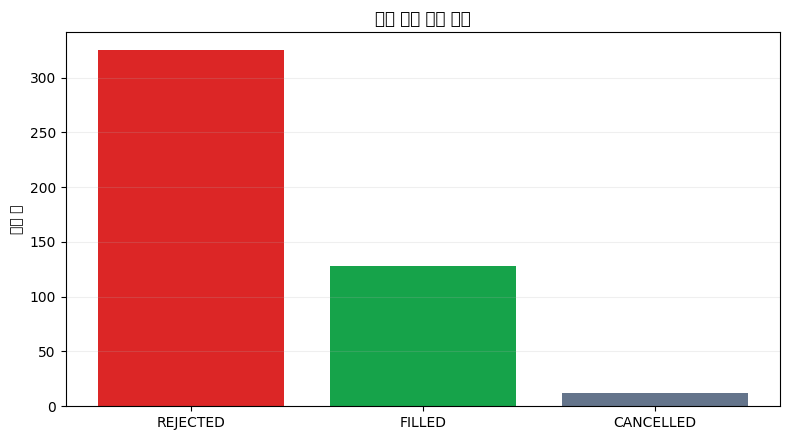

,status,orders
0,REJECTED,325
1,FILLED,128
2,CANCELLED,12


In [4]:
status = orders['status'].value_counts().rename_axis('status').reset_index(name='orders')
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(status['status'], status['orders'], color=['#dc2626', '#16a34a', '#64748b'][:len(status)])
ax.set_ylabel('주문 수')
ax.set_title('실제 주문 최종 상태')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()
status

In [5]:
quality = pd.DataFrame([
    {'check': '체결가 보유율', 'value': ledger['data_quality']['fill_price_coverage']},
    {'check': 'executions 연결률', 'value': ledger['data_quality']['execution_table_coverage_of_filled_orders']},
    {'check': '기록 수수료·세금 0 비율', 'value': ledger['data_quality']['zero_recorded_commission_tax_rate']},
    {'check': '현재 보유수량 정확 일치율', 'value': ledger['reconciliation']['endpoint_held_position_match_rate']},
])
quality.style.format({'value': '{:.1%}'})

,check,value
0,체결가 보유율,96.1%
1,executions 연결률,62.5%
2,기록 수수료·세금 0 비율,100.0%
3,현재 보유수량 정확 일치율,50.0%


In [6]:
positions.loc[
    (positions['actual_endpoint_qty'] != 0) | (positions['qty_gap_balancing_entry'] != 0),
    ['stock_name', 'symbol', 'known_fill_net_qty', 'actual_endpoint_qty', 'qty_gap_balancing_entry', 'exact_qty_match']
].sort_values(['actual_endpoint_qty', 'stock_name'], ascending=[False, True])

,stock_name,symbol,known_fill_net_qty,actual_endpoint_qty,qty_gap_balancing_entry,exact_qty_match
16,한국타이어앤테크놀로지,161390,475.0,1001.0,526.0,False
21,F&F,383220,915.0,915.0,0.0,True
10,코웨이,21240,2070.0,753.0,-1317.0,False
23,달바글로벌,483650,299.0,299.0,0.0,True
15,GS,78930,-39.0,0.0,39.0,False
14,LG씨엔에스,64400,1826.0,0.0,-1826.0,False
13,SK,34730,-557.0,0.0,557.0,False
9,더존비즈온,12510,1378.0,0.0,-1378.0,False
5,삼성전기,9150,127.0,0.0,-127.0,False
19,에이피알,278470,-9.0,0.0,9.0,False


종목 표기는 코드만 노출하지 않고 DB의 한글 종목명과 코드를 함께 사용한다. 현재 보유 4종목 중 알려진 체결만으로 수량이 일치하는 종목은 2개다.

## 재진입 확인 조건 실험

In [7]:
labels = {row['code']: row['label'] for row in full['metadata']['variant_definitions']}
variants = ['A_CURRENT', 'X_COOLDOWN5', 'R_EXIT_RECOVERY', 'R_TREND_REARM', 'C_CAP10', 'C_CAP08']
rows = []
for variant in variants:
    f = full['summary'][variant]
    r = recent['summary'][variant]
    rows.append({
        'variant': variant,
        'label': labels[variant],
        'full_return': f['total_return'],
        'full_mdd': f['max_drawdown'],
        'full_turnover': f['annualized_turnover'],
        'recent_return': r['total_return'],
        'recent_mdd': r['max_drawdown'],
        'recent_turnover': r['annualized_turnover'],
        'blocked_sessions': r['reentry_blocked_sessions'],
        'confirmed_reentries': r['confirmed_reentries'],
    })
comparison = pd.DataFrame(rows).set_index('variant')
comparison.style.format({
    'full_return': '{:.2%}', 'full_mdd': '{:.2%}', 'full_turnover': '{:.1f}x',
    'recent_return': '{:.2%}', 'recent_mdd': '{:.2%}', 'recent_turnover': '{:.1f}x',
})

,label,full_return,full_mdd,full_turnover,recent_return,recent_mdd,recent_turnover,blocked_sessions,confirmed_reentries
variant,,,,,,,,,
A_CURRENT,현재 규칙 근사,22.31%,-23.19%,21.4x,-1.75%,-19.06%,45.8x,0,0
X_COOLDOWN5,진단: 현재+5일 재진입 금지,18.08%,-20.40%,17.7x,-4.55%,-19.77%,34.2x,0,0
R_EXIT_RECOVERY,청산가 회복 2일 확인,18.81%,-23.92%,15.1x,-3.46%,-19.04%,27.8x,438,20
R_TREND_REARM,추세 재무장 3일 확인,10.87%,-27.06%,13.4x,-0.03%,-17.16%,23.7x,492,14
C_CAP10,종목 상한 10%,16.07%,-16.73%,13.7x,-1.83%,-14.94%,28.7x,0,0
C_CAP08,종목 상한 8%,13.22%,-13.66%,10.7x,-1.29%,-12.05%,22.9x,0,0


C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\1732281185.py:12: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\1732281185.py:12: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\1732281185.py:12: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\1732281185.py:12: UserWarning: Glyph 52825 (\N{HANGUL SYLLABLE CIG}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\1732281185.py:12: UserWarning: Glyph 44540 (\N{HANGUL SYLLABLE GEUN}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_19272\1732281185.py:12: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from current font.

C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) m

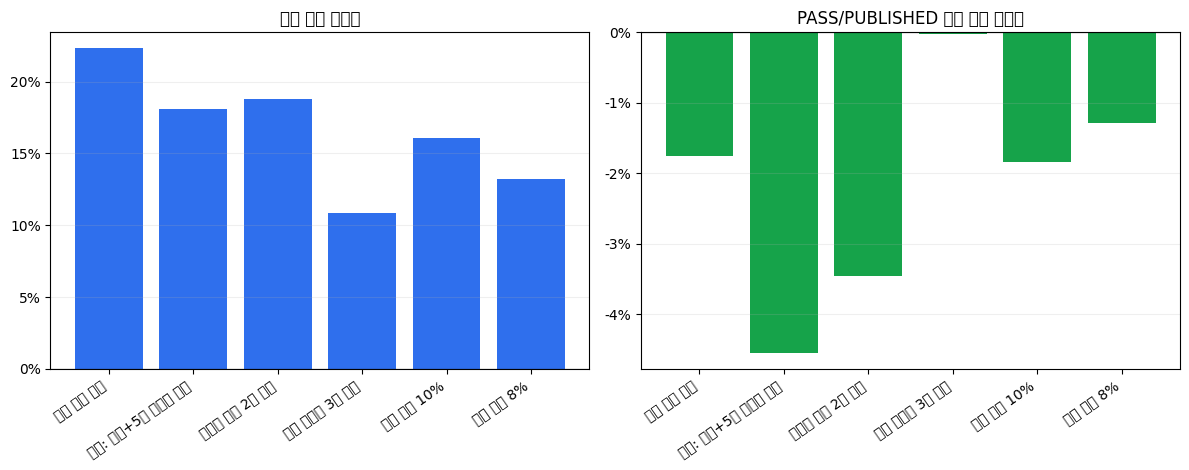

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
x = range(len(variants))
axes[0].bar(x, comparison.loc[variants, 'full_return'], color='#2f6fed')
axes[0].set_title('전체 구간 수익률')
axes[1].bar(x, comparison.loc[variants, 'recent_return'], color='#16a34a')
axes[1].set_title('PASS/PUBLISHED 최근 구간 수익률')
for ax in axes:
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(list(x), [labels[v] for v in variants], rotation=35, ha='right')
    ax.yaxis.set_major_formatter(lambda value, pos: f'{value:.0%}')
    ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

추세 재무장 3일 확인은 최근 구간에서 현재 규칙의 -1.75%를 -0.03%로 줄이고, MDD를 -19.06%에서 -17.16%, 연환산 회전율을 45.8배에서 23.7배로 낮췄다. 그러나 전체 구간 수익률은 +22.31%에서 +10.87%로 낮아지고 MDD는 -23.19%에서 -27.06%로 나빠졌다. 따라서 전면 적용 근거가 아니라 최근 고회전 구간의 shadow 후보로 해석한다.

## 검증과 의사결정

In [9]:
bridge_total = pnl.loc[pnl['classification'] != 'EXACT_ENDPOINT', 'amount'].sum()
assert ledger['metadata']['mode'] == 'PAPER'
assert abs(bridge_total - ledger['endpoint']['total_pnl']) < 1.0
assert ledger['order_result_replay']['orders'] == len(orders)
assert ledger['reconciliation']['endpoint_held_positions'] == 4
assert recent['summary']['R_TREND_REARM']['total_return'] > recent['summary']['A_CURRENT']['total_return']

checks = pd.DataFrame([
    {'check': 'PAPER 모드', 'result': 'PASS'},
    {'check': '손익 브리지 합계', 'result': 'PASS'},
    {'check': '주문 행 수 일치', 'result': 'PASS'},
    {'check': '현재 보유 4종목 확인', 'result': 'PASS'},
    {'check': '최근 구간 추세 재무장 개선', 'result': 'PASS'},
])
checks

,check,result
0,PAPER 모드,PASS
1,손익 브리지 합계,PASS
2,주문 행 수 일치,PASS
3,현재 보유 4종목 확인,PASS
4,최근 구간 추세 재무장 개선,PASS


1. 운영 전략은 즉시 변경하지 않는다.
2. 현재 규칙과 `R_TREND_REARM`을 10거래일 PAPER shadow로 병렬 기록한다.
3. 일별 리포트에 주문 최종상태, 체결 연결률, 수량 조정항목, 회전율, 비용을 필수 지표로 추가한다.
4. shadow 기간 동안 최근 수익률·MDD·회전율이 모두 개선되고 수량 불일치가 해소될 때만 승격을 재검토한다.